In [1]:
# CELL 1 — Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

SILVER_PATH = r"C:\Users\Lenovo\Downloads\nyc_taxi_project\silver\yellow_trips_silver.parquet"
GOLD_PATH   = r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold"

df = pd.read_parquet(SILVER_PATH)
print(f"Loaded {len(df):,} records")

Loaded 2,883,081 records


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24924\3418786352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly, x="pickup_hour", y="total_trips", palette="Blues_d")


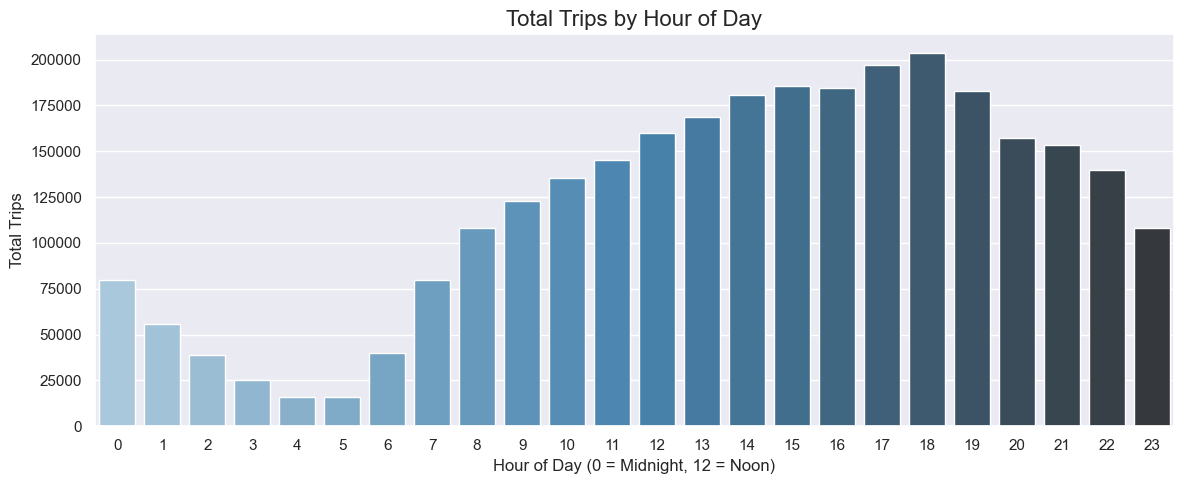

In [2]:
# CELL 2 — Trips by hour of day
hourly = df.groupby("pickup_hour")["pickup_hour"].count().reset_index(name="total_trips")

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x="pickup_hour", y="total_trips", palette="Blues_d")
plt.title("Total Trips by Hour of Day", fontsize=16)
plt.xlabel("Hour of Day (0 = Midnight, 12 = Noon)")
plt.ylabel("Total Trips")
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold\chart_trips_by_hour.png")
plt.show()

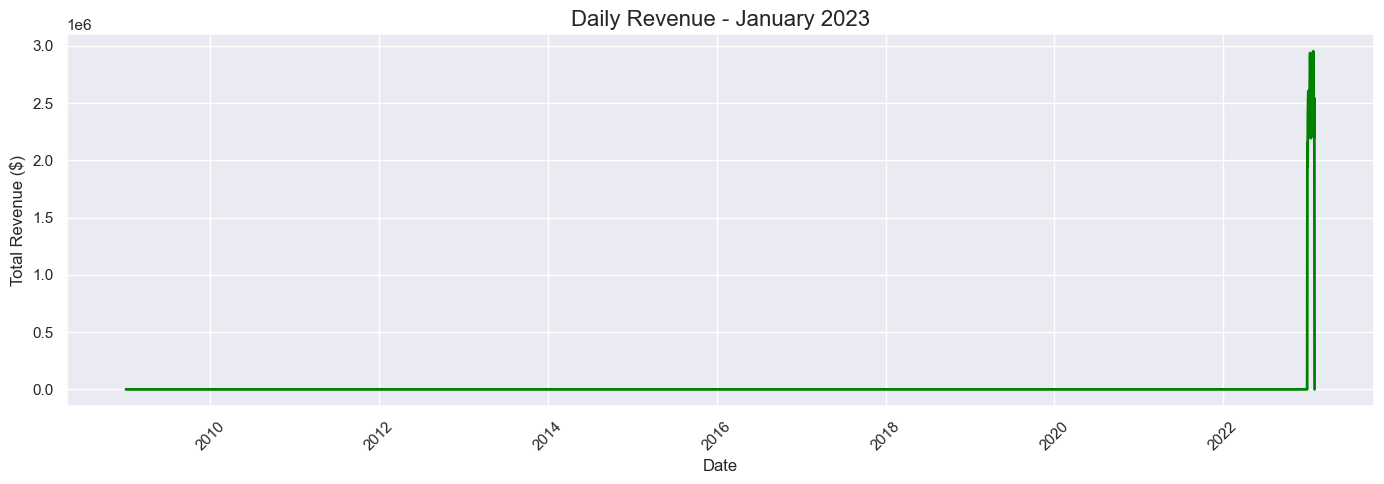

In [3]:
# CELL 3 — Daily revenue line chart
daily = (df.groupby("pickup_date")["total_amount"]
           .sum()
           .reset_index(name="daily_revenue"))

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="pickup_date", y="daily_revenue", color="green", linewidth=2)
plt.title("Daily Revenue - January 2023", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold\chart_daily_revenue.png")
plt.show()

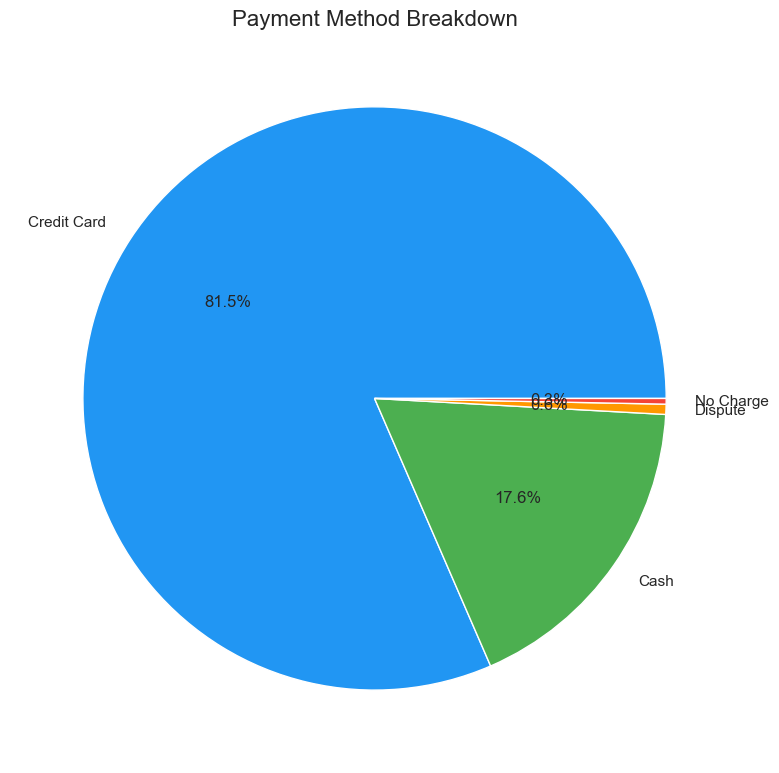

In [4]:
# CELL 4 — Payment method pie chart
payment = df["payment_type_label"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment, labels=payment.index, autopct="%1.1f%%",
        colors=["#2196F3", "#4CAF50", "#FF9800", "#F44336"])
plt.title("Payment Method Breakdown", fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold\chart_payment_breakdown.png")
plt.show()

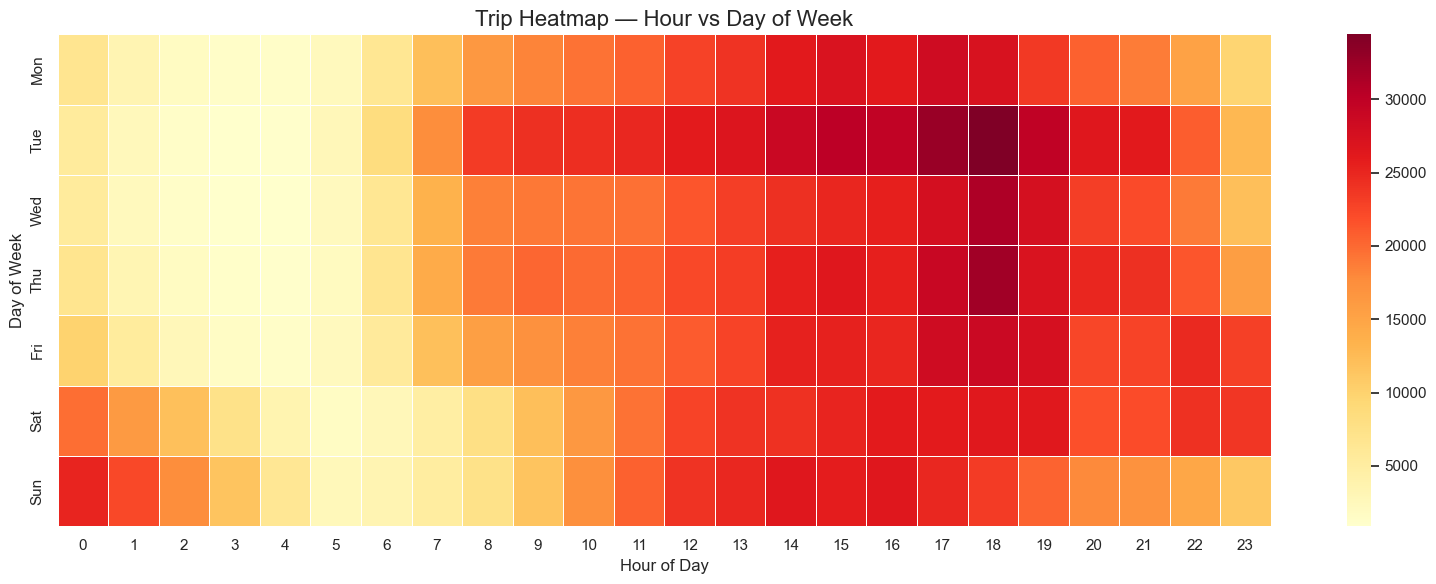

In [5]:
# CELL 5 — Heatmap: trips by hour vs day of week
pivot = df.groupby(["pickup_day_of_week", "pickup_hour"]).size().unstack()
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(16, 6))
sns.heatmap(pivot, cmap="YlOrRd", fmt=",", linewidths=0.5)
plt.title("Trip Heatmap — Hour vs Day of Week", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold\chart_heatmap.png")
plt.show()

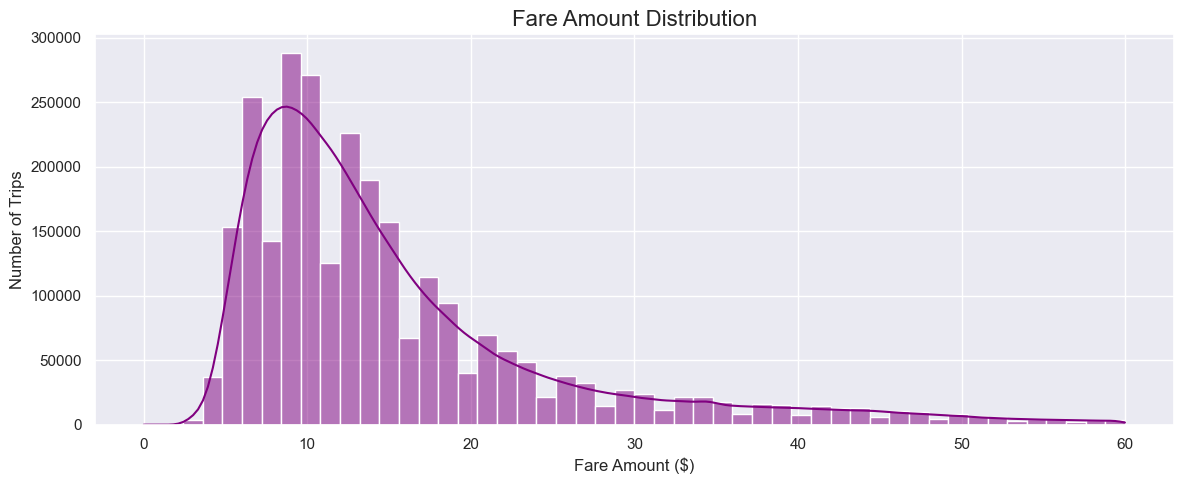

In [6]:
# CELL 6 — Fare distribution
plt.figure(figsize=(12, 5))
sns.histplot(df[df["fare_amount"] < 60]["fare_amount"], bins=50, color="purple", kde=True)
plt.title("Fare Amount Distribution", fontsize=16)
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Downloads\nyc_taxi_project\gold\chart_fare_distribution.png")
plt.show()